# **Leggi di conservazione: esercizi**

Si consideri il seguente problema di trasporto lineare
</br></br>
\begin{equation*}
\dfrac{\partial u}{\partial t} + \dfrac{\partial (v \,u)}{\partial x} = 0
\end{equation*}
sul dominio $\Omega=[0,5]$ e nell'intervallo temporale $(0,5]$.
Scegliamo $v=1$ e dato che la velocità è positiva il bordo di inflow è $x=0$, dove imponiamo la condizione $u=0$. Al bordo destro, $x=5$, non prescriviamo alcuna condizione.

Il dato iniziale è
</br></br>
$$
u_0(x) =
	\begin{cases}
		1 & \text{per}\ 1\le x\le2, \\
		0 & \text{altrimenti}.
	\end{cases}
$$
Si consideri la seguente **function** che risolve il problema di trasporto con il metodo dei Volumi Finiti:

      def fv_solve(u0, f, df, L, T, h, dt, flux_function)
        #
        return xc, t, u

Questa function prende in **input**:
* $u_0$: dato iniziale, 
* $\texttt{f}$: la funzione di flusso, 
* $\texttt{df}$: la sua derivata prima del flusso, 
* $L$: la lunghezza del dominio $\Omega=[0, L]$,
* $T$: tempo finale, 
* $h$: la spaziatura della griglia spaziale,
* $dt$: la spaziatura della griglia temporale, 
* il parametro $\texttt{flux\_function}$ corrisponde ad una funzione flusso (nel nostro caso sarà quella che implementarà il flusso di *upwind* e *Godunov*). 
	
L'**output** consiste:
* $\texttt{xc}$: il vettore dei punti medi delle celle, 
* $\texttt{t}$: il vettore degli istanti di tempo discreti, 
* $\texttt{u}$: matrice le cui colonne corrispondono ai valori che la soluzione assume ad ogni istante temporale in ogni intervallo di discretizzazione.

*Osservazione: le condizioni al contorno vengono imposte in automatico (inflow primo estremo) come condizione iniziale ad ogni istante di tempo*. 

In [1]:
from utilis_solver_cl import fv_solve
from utilis_plot_cl import xtplot

In [2]:
import numpy as np
# Dati del problema 1: trasporto lineare
# velocità
v = 1
# definire la u_0
u0 = lambda x: 1* (x>1)*(x<2)
# definire la f
f =  lambda u: v*u
# definire la df
df = lambda u: v+ 0*u #perché se u è vettoriale devo ottenere un vettore per df, quindi se non mettessi +0*u avrei sempre uno scalare
# lunghezza di Omega
L=5
# Istante di tempo finale
T=5

<mark>**Esercizio 1.1**</mark></br>
Calcolare il passo temporale massimo che soddisfa la **condizione CFL** con i dati forniti e il corrispondente numero di passi temporali $N_t$, quando il numero di sottointervalli in cui è suddiviso il dominio spaziale è $N=40$.

In [3]:
# N suddivisione spazio
N = 40
# passo spaziale
h=L/N
# Nt suddivisione temporale
Nt = N #perché condizione CFL è soddisfatta per >= quindi prendo =
# passo temporale
dt = T/Nt

<mark>**Esercizio 1.2**</mark></br>
Implementare una *funzione* che calcoli il flusso numerico per il metodo **upwind** in un dato intervallo. Utilizzare la seguente intestazione:

    def upwind_flux(f, df, uL, uR)
      #
      # implementazione
      #
      return F

dove:

*  $\texttt{f}$ e $\texttt{df}$: due lambda function corrispondenti alla funzione di flusso e alla sua derivata prima

* $\texttt{uL}$ e $\texttt{uR}$: due vettori contenenti tutti i valori della soluzione all'estremo sinistro e destro, rispettivamente, di ogni cella.

L'output $\texttt{F}$ consiste in un vettore contenente tutti i valori del flusso numerico nelle celle della griglia spaziale.

In [4]:
# # Implementazione del flusso "alla upwind"
def upwind_flux(f,df,uL,uR):
  """
  Input:
    f  (lambda function)
    df (lambda function)
    uL (numpy.ndarray)
    uR (numpy.ndarray)
    Output:
    F (numpy.ndarray)
  """
  F=[]
  for i in range (len(uL)):
    #verifica della monotonia del flusso
    if (df(uL[i])*df(uR[i])<0):
      raise RuntimeError ('il metrodo upwind non si può applicare')
    else: 
      if (df(uL[i])>=0):
        F.append(f(uL[i]))
      else:
        F.append(f(uR[i]))
  return np.array(F)


<mark>**Esercizio 1.3**</mark></br>
Fissato h, risolvere il problema dato scegliendo $N_t$, $N_t-1$ e $2N_t$ passi temporali.

Plottare i grafici delle soluzioni approssimate utilizzando la function $\verb|xtplot|$ in **utilis_plot_cl.py** e commentare i risultati ottenuti.


il passo temporale dt è: 0.125000
il passo spaziale h è: 0.125000
La condizione CFL è: True


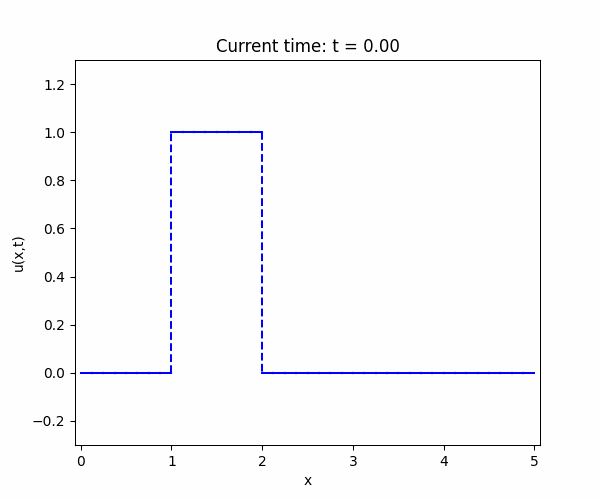

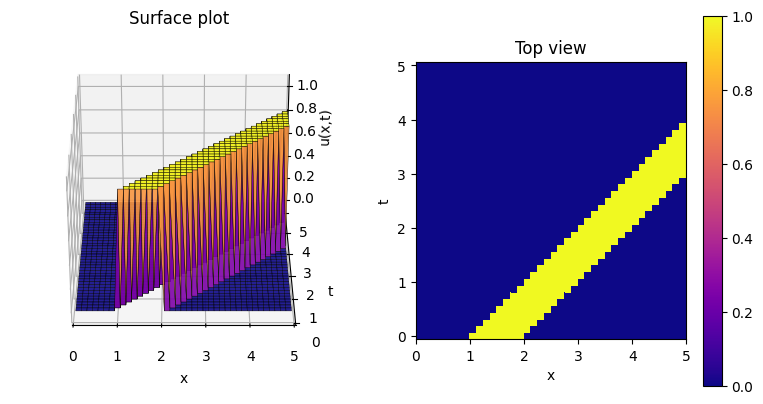

In [5]:
# rappresentazione grafica per Nt
dt = T/Nt 
print("il passo temporale dt è: %f" % (dt))
print("il passo spaziale h è: %f" % (h))
print("La condizione CFL è: %s" % ((dt/h) <= 1/abs(v)))

xc, t, u =fv_solve(u0, f, df, L, T, h, dt, upwind_flux)
xtplot(xc, t, u, 'animation', name_gif='es1_3') #per avere disegno con animazione
xtplot(xc, t, u, 'surface') #per avere disegno della superficie, per non dover vedere sempre l'animazione

#in questo caso osserviamo il trasporto

il passo temporale dt è: 0.128205
il passo spaziale h è: 0.125000
La condizione CFL è: False


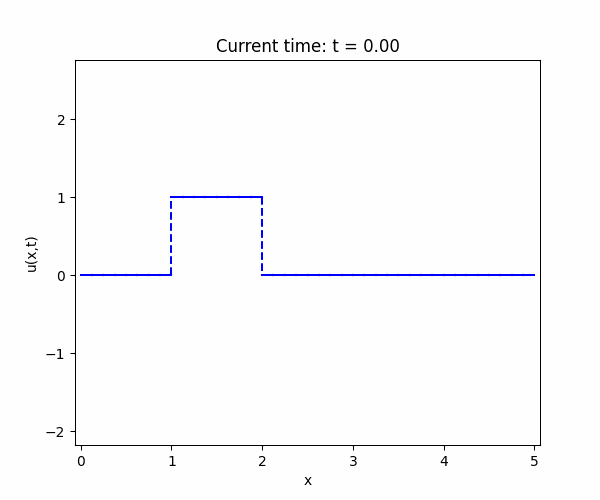

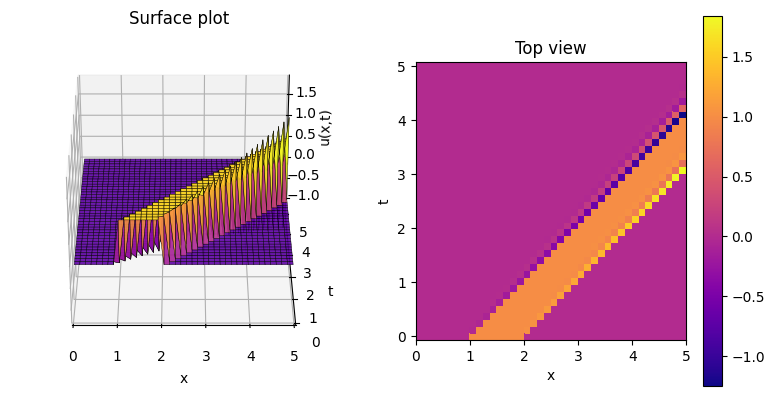

In [5]:
# rappresentazione grafica per Nt-1
dt = T/(Nt-1)
print("il passo temporale dt è: %f" % (dt))
print("il passo spaziale h è: %f" % (h))
print("La condizione CFL è: %s" % ((dt/h) <= 1/abs(v)))

xc, t, u =fv_solve(u0, f, df, L, T, h, dt, upwind_flux)

xtplot(xc, t, u, 'animation', name_gif='es1_3') 
xtplot(xc, t, u, 'surface')
#vediamo che la CFL NON è verificata, infatti ci sono oscillazioni


il passo temporale dt è: 0.062500
il passo spaziale h è: 0.125000
La condizione CFL è: True


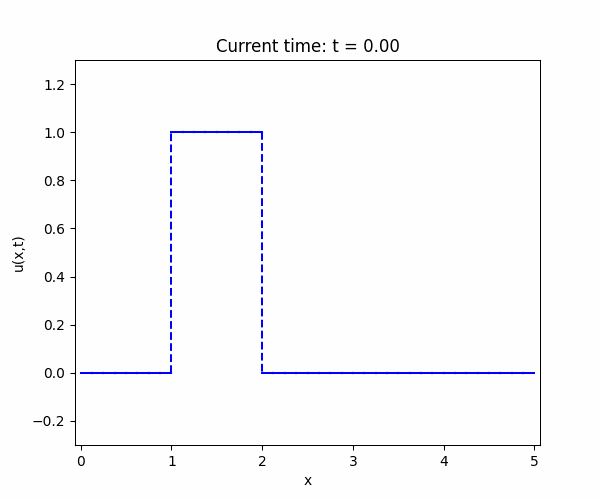

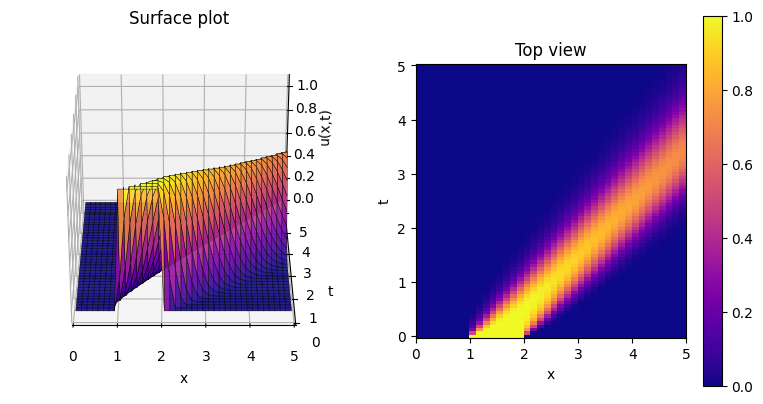

In [6]:
# rappresentazione grafica per 2*Nt
dt = T/(2*Nt)
print("il passo temporale dt è: %f" % (dt))
print("il passo spaziale h è: %f" % (h))
print("La condizione CFL è: %s" % ((dt/h) <= 1/abs(v)))

xc, t, u =fv_solve(u0, f, df, L, T, h, dt, upwind_flux)

xtplot(xc, t, u, 'animation', name_gif='es1_3') 
xtplot(xc, t, u, 'surface')
#vediamo che la CFL è verificata, infatti c'è sia trasporto che diffusione numerica, cioé la curva piano piano si abbassa


<mark>**Esercizio 2**</mark></br>
Si consideri ora l'equazione di Burgers:
\begin{equation*}
\dfrac{\partial u}{\partial t} + \dfrac{\partial}{\partial x} \left(\dfrac{u^2}{2}\right)= 0
\end{equation*}
sul dominio $\Omega=[0,5]$ e nell'intervallo temporale $(0,10]$, con condizione iniziale
\begin{equation*}
	u_0(x) =
	\begin{cases}
		4(x-1)(2-x) & \text{per}\ 1\le x\le2, \\
		0 & \text{altrimenti}.
	\end{cases}
\end{equation*}
Anche in questo caso imponiamo la condizione di *inflow* sul bordo sinistro, $u(0,t)=0$ per ogni $t\in(0,10]$. 
</br>
Osserviamo quindi che, più in generale, se $u\ge0$, il bordo sinistro è di inflow.


<mark>**Esercizio 2.1**</mark></br>
Rappresentare in un grafico l'andamento della funzione flusso $f(u)$ e della sua derivata prima $f^\prime(u)$ per $0\leq u\leq 1$.


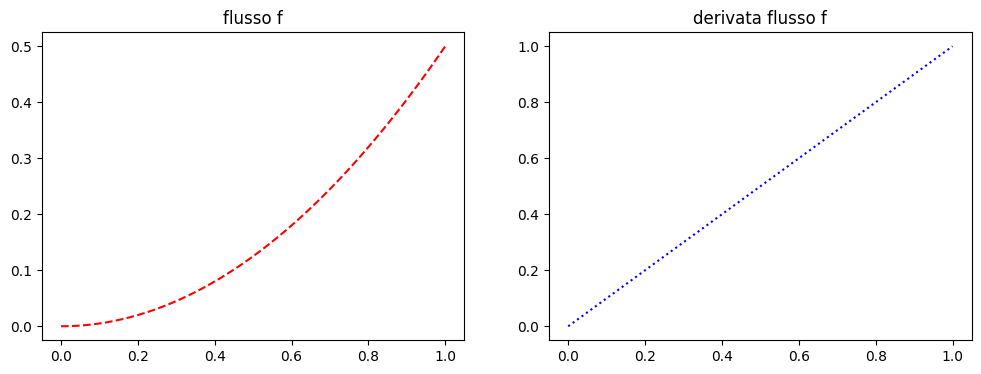

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Dati del problema
# definire la u_0
u0 = lambda x: -4*(x-1)*(x-2)*(x<2)*(x>1)
# definire la f
f =  lambda u: 0.5*u*u
# definire la df
df = lambda u: u
# lunghezza di Omega
L=5
# Istante di tempo finale
T=10

xx= np.linspace(0,1,1000)
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(xx,f(xx),'--r')
plt.title('flusso f')
plt.subplot(122)
plt.plot(xx,df(xx),':b')
plt.title('derivata flusso f');
plt.show()
#osserviamo che il flusso è una parabola e la sua derivata una retta

<mark>**Esercizio 2.2**</mark></br>
In base ai risultati del punto precedente, il metodo Upwind è applicabile? Risolvere il problema prendendo $N=40$ e $Nt=80$.

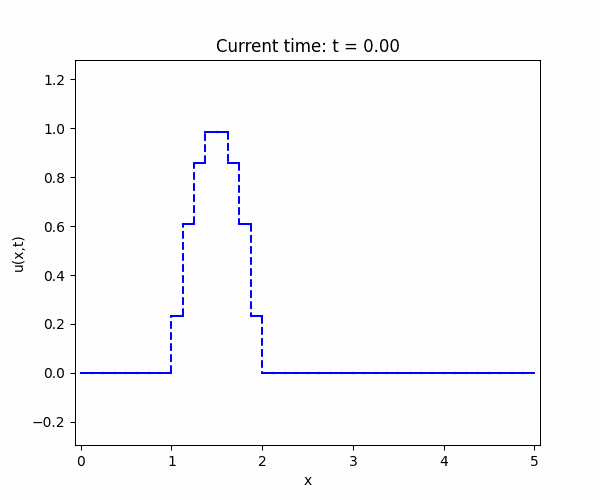

In [7]:
# N suddivisione spazio
N=40
# passo spaziale
h=L/N
# Nt suddivisione temprale
Nt = 2*N

# rappresentazione grafica per Nt
dt = T/Nt

xc, t, u =fv_solve(u0, f, df, L, T, h,dt, upwind_flux)

xtplot( xc, t, u, 'animation')
#vediamo dall'animazione che il flusso non è lineare e la sua derivata non è una costante ma una retta, quindi ci aspettiamo che
# una parte si muova più velocemente  

<mark>**Esercizio 3**</mark></br>
Si consideri ora l'equazione del traffico
\begin{equation*}
\dfrac{\partial u}{\partial t} + \dfrac{\partial }{\partial x}f(u)=0
\end{equation*}
sul dominio $\Omega=[0, 5]$ e nell'intervallo temporale $(0,10]$.
Qui la funzione f è la seguente:
\begin{equation*}
f(u)=v\,u\left(1-\dfrac{u}{u_{max}}\right).
\end{equation*}
$v$ indica una velocità che viene modulata in funzione della densità di auto $u$. In particolare quando $u$ raggiunge il valore massimo $u_{max}$ il flusso si annulla (traffico bloccato). La condizione al contorno $u(0,t)=u_0(0)$


<mark>**Esercizio 3.1**</mark></br>
Dopo aver scelto $v=1$ e $u_{max}=1$, rappresentare la funzione flusso e la sua derivata per $0\leq u \leq 1$.


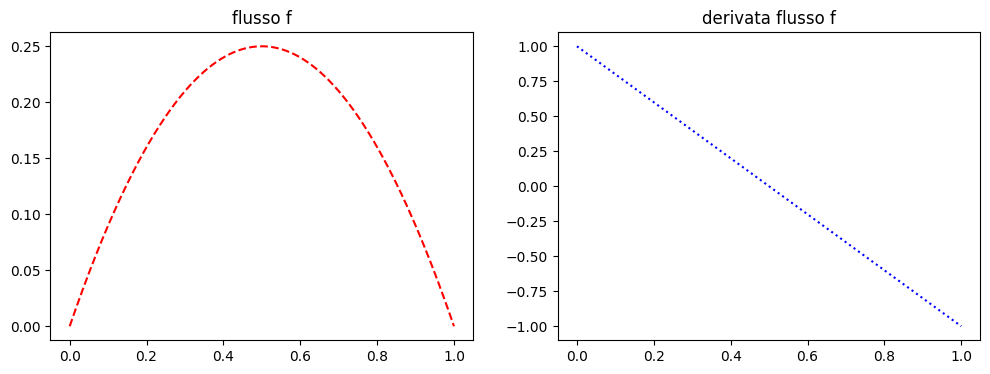

In [22]:
# Dati del problema
v = 1;
umax = 1;
# definire la f
f =  lambda u: v*u*(1-u/umax);
# definire la df
df = lambda u: v*(1-2*u/umax);

plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(xx,f(xx),'--r')
plt.title('flusso f')
plt.subplot(122)
plt.plot(xx,df(xx),':b')
plt.title('derivata flusso f');
plt.show()


<mark>**Esercizio 3.2**</mark></br> In base al punto precedente, il metodo Upwind è applicabile?


In [ ]:
# no perché il fljusso non è monotono, pendenza cambia di segno 

<mark>**Flusso di Godunov**</mark></br>

Si consideri la funzione $\verb|godunov_flux|$ che implementa il calcolo del flusso numerico *Godunov*.

In [23]:
def godunov_flux(f,df, uL, uR):
    """
    Calcola il flusso di Godunov generico:
    - f: funzione di flusso 
    - df: derivata del flusso (in questo caso muta)
    - uL, uR: array sinistra e destra delle celle
    """
    N = len(uL)
    F = np.zeros(N) 

    for i in range(N):
        ul = uL[i]
        ur = uR[i]

        if ul == ur:
            F[i] = f(ul)
        else:
            u_min, u_max = min(ul, ur), max(ul, ur)
            u_sample = np.linspace(u_min, u_max, 1000)
            f_sample = f(u_sample)
            if ul < ur:
                F[i] = np.min(f_sample)
            else:
                F[i] = np.max(f_sample)
    return F



<mark>**Esercizio 3.3**</mark></br>

Applicando il flusso numerico di *Godunov*, risolvere il problema del traffico con coda al semaforo, descritto dalla condizione iniziale
\begin{equation*}
	u_0(x) =
	\begin{cases}
		u_{max} & \text{per}\ x\le2, \\
		\frac{1}{8}u_{max} & \text{per}\ x>2
	\end{cases}
\end{equation*}
e prendendo $N=40$ e $N_t=80$. Cosa si osserva?

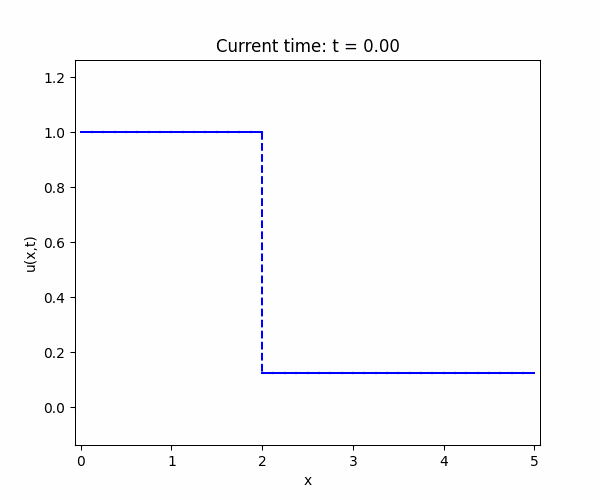

In [25]:
# definire la u_0
u0 = lambda x: 1.0*(x<=2)+1/8*(x>2)
L=5
# N suddivisione spazio
N=40
# passo spaziale
h=L/N
# tempo finale
T=10
# scelta de Nt
Nt=80
# scelta di dt
dt=T/Nt

xc, t, u= fv_solve(u0, f, df, L, T, h, dt, godunov_flux)

xtplot(xc, t, u, 'animation')

<mark>**Esercizio 3.4**</mark></br>
Risolvere il problema del traffico con condizione iniziale
</br></br>
$$
	u_0(x) =
	\begin{cases}
		\frac{1}{8}u_{max} & \text{per}\ x\le2, \\
		u_{max} & \text{per}\ x>2
	\end{cases}
$$
</br>
con gli stessi dati di prima. Cosa si osserva?

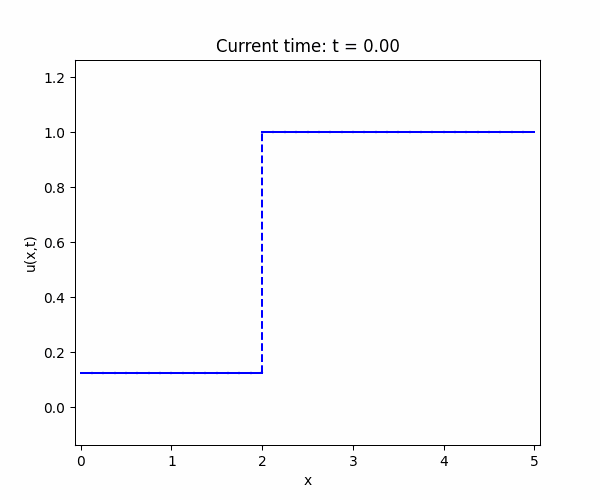

In [26]:
# definire la u_0
u0 = lambda x: 1.0*(x>2)+1/8*(x<=2)

xc, t, u= fv_solve(u0, f, df, L, T, h, dt, godunov_flux)

xtplot(xc, t, u, 'animation')